In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy .stats as stats
from scipy .stats import shapiro
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


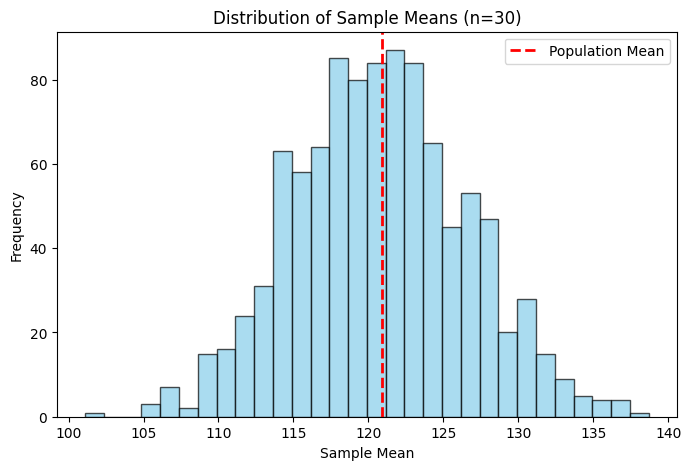

In [8]:
sample_means = []
n_samples = 1000 
sample_size = 30

for _ in range(n_samples):
    sample = df['Glucose'].sample(n=sample_size, replace=True)
    sample_means.append(sample.mean())

plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=30, edgecolor='k', alpha=0.7, color='skyblue')
plt.axvline(df['Glucose'].mean(), color='red', linestyle='dashed', linewidth=2, label='Population Mean')
plt.title(f'Distribution of Sample Means (n={sample_size})')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Shapiro-Wilk p-value: 1.9863474999979633e-11
Result: Not normally distributed (Reject H0)


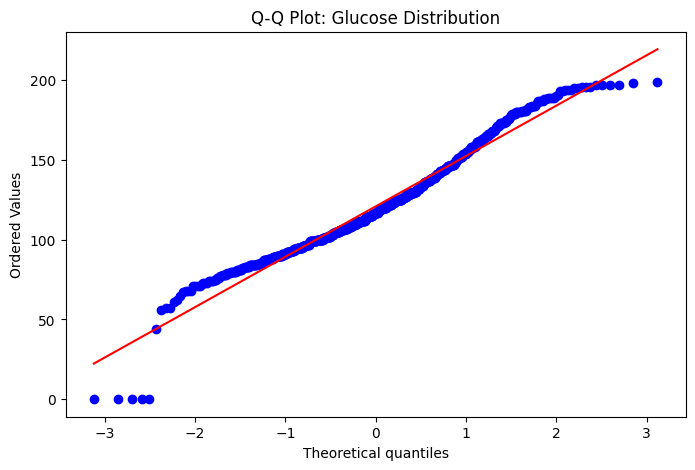

In [9]:
shapiro_test = stats.shapiro(df['Glucose'])
print("Shapiro-Wilk p-value:", shapiro_test.pvalue)


if shapiro_test.pvalue < 0.05:
    print("Result: Not normally distributed (Reject H0)")
else:
    print("Result: Normally distributed (Fail to reject H0)")


plt.figure(figsize=(8, 5))
stats.probplot(df['Glucose'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Glucose Distribution') 
plt.show()